# Challenge 3: evaluación final e inferencia

El modelo ya fue seleccionado. Ahora debes abrir el conjunto de test una sola vez, comunicar su desempeño y comprobar que el pipeline puede reutilizarse con datos nuevos.

**Entradas:** `test.csv`, `data_contract.json` y `champion_model.joblib`  
**Salidas:** `test_metrics.json`, `batch_predictions.csv`

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)

In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in (PROCESSED_DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Carga del modelo y del conjunto de prueba

In [3]:
contract = json.loads((ARTIFACTS_DIR / "data_contract.json").read_text(encoding="utf-8"))
training_metadata = json.loads((ARTIFACTS_DIR / "training_metadata.json").read_text(encoding="utf-8"))
model = joblib.load(ARTIFACTS_DIR / "champion_model.joblib")

test_df = pd.read_csv(PROCESSED_DATA_DIR / "test.csv")
X_test = test_df[contract["features"]]
y_test = test_df[contract["target"]]

print("Modelo:", training_metadata["champion"])
print("Test:", X_test.shape)

Modelo: logistic_regression
Test: (36, 13)


## 2. Evaluación final

Accuracy test: 0.9722
F1 macro test: 0.971
Accuracy CV  : 0.9791

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



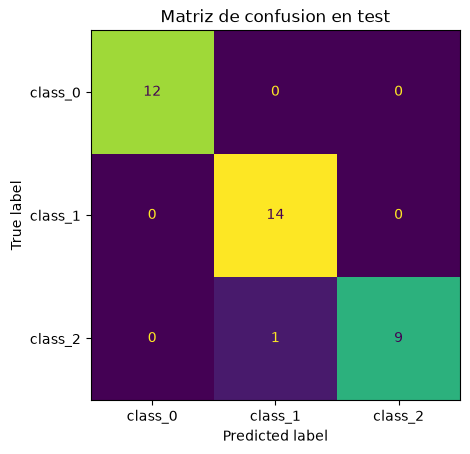

In [4]:
y_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy test:", round(test_accuracy, 4))
print("F1 macro test:", round(test_f1, 4))
print("Accuracy CV  :", round(training_metadata["cv_score"], 4))
print()
print(classification_report(y_test, y_pred, target_names=contract["target_names"]))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=contract["target_names"], colorbar=False)
plt.title("Matriz de confusion en test")
plt.show()

**Análisis:**

> Sí es coherente. En test la accuracy fue 0.972 y el F1 macro 0.971, muy parecido al 0.979 de validación cruzada. El modelo solo se equivocó en 1 de los 36 vinos: un vino de la clase 2 lo predijo como clase 1, por eso la clase 2 tiene recall de 0.90 y la clase 1 precisión de 0.93. La clase 0 la clasificó perfecto. Esto concuerda con el EDA, donde la clase 0 era la más separada (proline alto) y las clases 1 y 2 se parecían más en algunas variables. No veo evidencia de sobreajuste porque el resultado en test no cayó frente a la validación cruzada. Igual hay que tener en cuenta que el test es muy pequeño y un solo error cambia la accuracy en casi 3 puntos.

## 3. Función de inferencia

In [5]:
feature_columns = contract["features"]
class_names = contract["target_names"]

def predict(records: pd.DataFrame) -> pd.DataFrame:
    """Valida el esquema y devuelve las predicciones del pipeline."""
    missing = sorted(set(feature_columns) - set(records.columns))
    if missing:
        raise ValueError(f"Faltan variables requeridas: {missing}")

    X = records[feature_columns]
    labels = model.predict(X)
    probabilities = model.predict_proba(X)

    result = pd.DataFrame({"prediction": labels}, index=records.index)
    result["predicted_class"] = [class_names[label] for label in labels]
    for i, name in enumerate(class_names):
        result[f"probability_{name}"] = probabilities[:, i]
    return result

## 4. Predicción por lotes

In [6]:
# Simulación de datos nuevos. En producción no provendrían del test set.
new_records = X_test.iloc[:5].copy()

batch_predictions = predict(new_records)
batch_predictions.to_csv(REPORTS_DIR / "batch_predictions.csv", index=False)
batch_predictions.round(3)

,prediction,predicted_class,probability_class_0,probability_class_1,probability_class_2
0,0,class_0,1.000,0.000,0.000
1,1,class_1,0.007,0.540,0.453
2,0,class_0,0.992,0.008,0.000
3,1,class_1,0.290,0.707,0.003
4,1,class_1,0.033,0.962,0.005


In [7]:
# pruebo que la validacion del esquema funcione si falta una columna
try:
    predict(new_records.drop(columns=["alcohol"]))
except ValueError as e:
    print("Error esperado:", e)

Error esperado: Faltan variables requeridas: ['alcohol']


## 5. Reporte final

In [8]:
test_metrics = {
    "model": training_metadata["champion"],
    "accuracy": float(test_accuracy),
    "f1_macro": float(test_f1),
}
(REPORTS_DIR / "test_metrics.json").write_text(json.dumps(test_metrics, indent=2), encoding="utf-8")
test_metrics

{'model': 'logistic_regression',
 'accuracy': 0.9722222222222222,
 'f1_macro': 0.9709618874773139}

In [9]:
assert (REPORTS_DIR / "test_metrics.json").exists()
assert (REPORTS_DIR / "batch_predictions.csv").exists()
print("Challenge 3 completado.")

Challenge 3 completado.


## Resumen ejecutivo

| Elemento | Resultado |
|---|---|
| Modelo campeón | Regresión logística (C = 1) con imputación por mediana y StandardScaler |
| Accuracy CV | 0.979 |
| Accuracy test | 0.972 |
| F1 macro test | 0.971 |
| Clases más confundidas | class_2 predicha como class_1 (1 caso) |
| Principal limitación | El dataset es muy pequeño (178 vinos, 36 en test), así que la estimación final tiene bastante incertidumbre |

## Checklist

- [x] Evalué únicamente el modelo campeón.
- [x] No reajusté hiperparámetros después de observar test.
- [x] Implementé validación básica del esquema de entrada.
- [x] Generé predicciones por lotes.
- [x] Guardé las métricas finales.